# CausalAgentBench — Agent Evaluation Demo

This notebook is inspired by the DeepLearning.AI **Evaluating AI Agents** course (using Arize Phoenix / LLM-as-judge). The notebook structure: 

1. Start a local Phoenix server for automatic OpenAI tracing
2. Run the financial analyst agent across prompt versions, temperatures, and models
3. Log run metadata and LLM-as-judge groundedness scores
4. Pull traces from Phoenix
5. Compare whether prompt version affects task success rate

In [1]:
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import phoenix as px
from dotenv import load_dotenv

# Project root (one level up from notebooks/)
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

True

## 1. Start Phoenix server

Phoenix collects traces automatically once `OpenAIInstrumentor` is enabled in the agent module.

In [2]:
import os

session = px.launch_app()
print(f"Phoenix UI: {session.url}")

from agents.financial_analyst_agent import PROJECT_NAME, PROMPT_VERSIONS, run_agent, setup_tracing
from tracking.evaluation_logger import EvaluationLogger, fetch_generate_summary_spans, log_groundedness_annotations_to_phoenix

# Send traces to this Phoenix instance (must run experiment after this cell)
phoenix_port = os.getenv("PHOENIX_PORT", "6006")
collector_endpoint = f"http://127.0.0.1:{phoenix_port}/v1/traces"
setup_tracing(endpoint=collector_endpoint)
print(f"Tracing project: {PROJECT_NAME}")
print(f"Collector: {collector_endpoint}")

C:\Users\tpodv\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_cumulative_llm_token_count_total
  next(self.gen)
C:\Users\tpodv\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_latency
  next(self.gen)
C:\Users\tpodv\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_spans_session_id
  next(self.gen)
boto3 is installed but aioboto3 is not. To use AWS Bedrock models in Playground, install aioboto3: pip install aioboto3


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
Phoenix UI: http://localhost:6006/
Tracing project: CausalAgentBench
Collector: http://127.0.0.1:6006/v1/traces


## 2. Run agent experiments

Run the agent 10–20 times with different prompt versions, temperatures, and models.


In [4]:
QUERY = "Compare AAPL and MSFT from 2026-01-01 to 2026-05-28."

experiment_grid = [
    {"prompt_version": pv, "temperature": temp, "model": "gpt-4o-mini"}
    for pv, temp in itertools.product(
        list(PROMPT_VERSIONS.keys()),
        [0.0, 0.2, 0.4, 0.6, 0.8],
    )
]

logger = EvaluationLogger(log_path=PROJECT_ROOT / "experiments" / "run_logs.csv")
run_records = []

for i, config in enumerate(experiment_grid, start=1):
    print(f"Run {i}/{len(experiment_grid)}: {config}")
    result = run_agent(QUERY, **config)
    record = logger.log_agent_result(result)
    run_records.append(record)

runs_df = pd.DataFrame(run_records)
runs_df.head()

Run 1/15: {'prompt_version': 'v1_brief', 'temperature': 0.0, 'model': 'gpt-4o-mini'}
Run 2/15: {'prompt_version': 'v1_brief', 'temperature': 0.2, 'model': 'gpt-4o-mini'}
Run 3/15: {'prompt_version': 'v1_brief', 'temperature': 0.4, 'model': 'gpt-4o-mini'}
Run 4/15: {'prompt_version': 'v1_brief', 'temperature': 0.6, 'model': 'gpt-4o-mini'}
Run 5/15: {'prompt_version': 'v1_brief', 'temperature': 0.8, 'model': 'gpt-4o-mini'}
Run 6/15: {'prompt_version': 'v2_detailed', 'temperature': 0.0, 'model': 'gpt-4o-mini'}
Run 7/15: {'prompt_version': 'v2_detailed', 'temperature': 0.2, 'model': 'gpt-4o-mini'}
Run 8/15: {'prompt_version': 'v2_detailed', 'temperature': 0.4, 'model': 'gpt-4o-mini'}
Run 9/15: {'prompt_version': 'v2_detailed', 'temperature': 0.6, 'model': 'gpt-4o-mini'}
Run 10/15: {'prompt_version': 'v2_detailed', 'temperature': 0.8, 'model': 'gpt-4o-mini'}
Run 11/15: {'prompt_version': 'v3_structured', 'temperature': 0.0, 'model': 'gpt-4o-mini'}
Run 12/15: {'prompt_version': 'v3_structure

,run_id,prompt_version,temperature,model,input_tokens,tool_calls_made,task_success,llm_judge_score,cost_usd,timestamp,summary,metrics,judge_explanation
0,ef2b3ad7-ad83-47d8-b4c0-f8de98d738a1,v1_brief,0.0,gpt-4o-mini,44864,"[""get_stock_data"", ""get_stock_data"", ""calculat...",True,0.0,0.011620,2026-06-02T02:36:16.233276+00:00,### Comparison Summary of AAPL and MSFT (2026-...,{},No metrics available to verify against.
1,c7c4319c-a180-4ed2-b804-1c0ce69ff248,v1_brief,0.2,gpt-4o-mini,36030,"[""get_stock_data"", ""get_stock_data"", ""calculat...",True,0.0,0.007643,2026-06-02T02:37:46.248900+00:00,### Comparison Summary of AAPL and MSFT (2026-...,{},No metrics available to verify against.
2,5b02743b-2377-4ba1-8b1a-7999bbe9a0ef,v1_brief,0.4,gpt-4o-mini,23060,"[""get_stock_data"", ""get_stock_data"", ""calculat...",True,0.0,0.005748,2026-06-02T02:39:05.916800+00:00,### Comparison Summary of AAPL and MSFT (2026-...,"{""AAPL"": {""cumulative_return"": 0.1491, ""annual...",The summary contains several inaccuracies and ...
3,9a60f6b3-75da-4ead-8a4f-a8b7e60b6242,v1_brief,0.6,gpt-4o-mini,23064,"[""get_stock_data"", ""get_stock_data"", ""calculat...",True,0.0,0.005706,2026-06-02T02:40:26.097246+00:00,### Comparison Summary of AAPL and MSFT (Jan 1...,"{""AAPL"": {""cumulative_return"": 0.1491, ""annual...","The summary for AAPL has incorrect metrics, sp..."
4,3b251b49-8d2a-4097-bace-6d2e7c124ab1,v1_brief,0.8,gpt-4o-mini,37005,"[""get_stock_data"", ""get_stock_data"", ""calculat...",True,0.0,0.008191,2026-06-02T02:41:50.476693+00:00,### Summary of AAPL vs MSFT Performance (Janua...,{},No metrics available to verify against.


## 3. Pull traces from Phoenix (SpanQuery)

Query `generate_summary` tool spans — the same pattern as Lab 3 in the course.

In [5]:
from phoenix.client import Client

# Load runs from CSV if experiment cell was not run in this kernel session
if "runs_df" not in globals():
    logger = EvaluationLogger(log_path=PROJECT_ROOT / "experiments" / "run_logs.csv")
    runs_df = logger.load_runs()
    print(f"Loaded {len(runs_df)} runs from experiments/run_logs.csv")

px_client = Client()
summary_spans_df = fetch_generate_summary_spans(px_client, project_name=PROJECT_NAME)
print(f"Retrieved {len(summary_spans_df)} generate_summary spans")
if summary_spans_df.empty:
    print("Tip: re-run Phoenix setup + experiment in the same session, then this cell again.")
summary_spans_df.head()

Retrieved 19 generate_summary spans


,context.span_id,name,span_kind,summary,span_id
0,62443c9acecb667e,generate_summary,TOOL,When comparing Apple Inc. (AAPL) and Microsoft...,62443c9acecb667e
1,2f656537cc3df1e9,generate_summary,TOOL,When comparing the financial metrics of Apple ...,2f656537cc3df1e9
2,54ad480cb016aa37,generate_summary,TOOL,When comparing the financial performance of Ap...,54ad480cb016aa37
3,449833be23f51d81,generate_summary,TOOL,When comparing the financial performance of Ap...,449833be23f51d81
4,e6f203053c52e7e5,generate_summary,TOOL,When comparing the financial performance of Ap...,e6f203053c52e7e5


## 4. Trace-linked LLM-as-judge evaluation

Join spans to run logs, score summary groundedness (with `suppress_tracing`), and log annotations back to Phoenix UI.

In [6]:
if runs_df.empty:
    raise ValueError("No runs found. Run the experiment cell or check experiments/run_logs.csv")

trace_eval_df = log_groundedness_annotations_to_phoenix(
    px_client,
    runs_df,
    project_name=PROJECT_NAME,
)

if not trace_eval_df.empty:
    trace_eval_df[["span_id", "summary", "llm_judge_score", "judge_explanation"]].head()
else:
    print("Skipped Phoenix annotations (no spans). Section 5 still works from CSV.")

## 5. Does prompt version affect task success rate?

Uses `experiments/run_logs.csv` — no Phoenix traces required.

In [7]:
if "logger" not in globals():
    logger = EvaluationLogger(log_path=PROJECT_ROOT / "experiments" / "run_logs.csv")

summary = logger.summarize_by_prompt_version()
summary

,prompt_version,runs,task_success_rate,avg_judge_score,avg_cost_usd
0,v1_brief,23,0.956522,0.043478,0.007189
1,v2_detailed,15,1.000000,0.400000,0.006968
2,v3_structured,15,1.000000,0.066667,0.010793


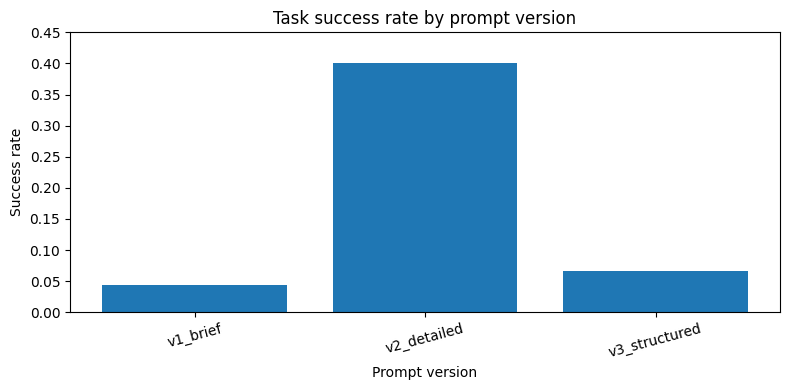

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary["prompt_version"], summary["avg_judge_score"])
ax.set_title("Task success rate by prompt version")
ax.set_xlabel("Prompt version")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 0.45)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---

## Next step: Causal Inference Analysis

> **Placeholder for DML / causal forests**

Once enough runs are logged, treat **prompt version** (and/or temperature, AI model) as the treatment and estimate its causal effect on:

- `task_success`
- `llm_judge_score`
- `cost_usd`

Planned approach:
1. Export `experiments/run_logs.csv` to `analysis/`
2. Fit double machine learning (DML) or causal forest models
3. Estimate ATE/CATE of prompt interventions while controlling for confounders (e.g., temperature, model)

```python
# TODO: causal inference pipeline
# from econml.dml import LinearDML
# treatment = runs_df["prompt_version"]
# outcome = runs_df["task_success"]
# ...
```